In [5]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# 1. 데이터 생성 (공부 시간, 수면 시간 → 합격 여부)
# [공부시간(h), 수면시간(h)] → 합격(1) / 불합격(0)
X = np.array([
    [2, 9], [3, 8], [4, 7], [5, 7], [6, 6],
    [7, 6], [8, 5], [9, 5], [1, 8], [2, 7],
    [3, 6], [4, 5], [5, 4], [6, 4], [7, 3],
    [8, 3], [9, 2], [1, 5], [2, 4], [3, 3]
])
y = np.array([0,0,0,1,1, 1,1,1,0,0, 0,0,1,1,1, 1,1,0,0,0])

# 2. 훈련/테스트 분리
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# 3. KNN 모델 학습 (K=3)
model = KNeighborsClassifier(n_neighbors=3)
model.fit(X_train, y_train)

# 4. 평가
y_pred = model.predict(X_test)
print("혼동 행렬:")
print(confusion_matrix(y_test, y_pred))
print("\n분류 리포트:")
print(classification_report(y_test, y_pred, target_names=['불합격','합격']))

# 5. 새 학생 예측
new_student = np.array([[6, 5]])  # 공부 6시간, 수면 5시간
result = model.predict(new_student)
print(f"\n공부 6h, 수면 5h → {'합격' if result[0]==1 else '불합격'} 예측")

혼동 행렬:
[[4 0]
 [0 2]]

분류 리포트:
              precision    recall  f1-score   support

         불합격       1.00      1.00      1.00         4
          합격       1.00      1.00      1.00         2

    accuracy                           1.00         6
   macro avg       1.00      1.00      1.00         6
weighted avg       1.00      1.00      1.00         6


공부 6h, 수면 5h → 합격 예측


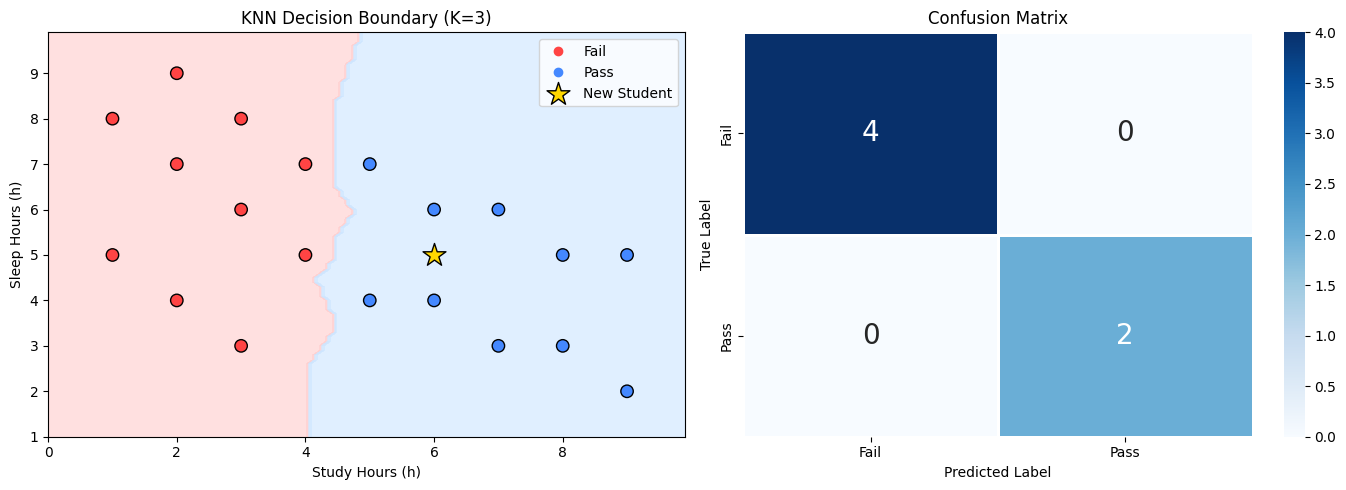

In [12]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from matplotlib.colors import ListedColormap
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix

# Removed Korean font settings to prevent errors
plt.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── 1. Decision Boundary Visualization ──────────────────────────
ax1 = axes[0]
h = 0.1
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

cmap_bg = ListedColormap(['#FFCCCC', '#CCE5FF'])
cmap_pt = ListedColormap(['#FF4444', '#4488FF'])

ax1.contourf(xx, yy, Z, cmap=cmap_bg, alpha=0.6)
scatter = ax1.scatter(X[:, 0], X[:, 1], c=y,
                      cmap=cmap_pt, edgecolors='k', s=80, zorder=3)
ax1.scatter(*new_student[0], c='gold', marker='*',
            s=300, edgecolors='k', zorder=4, label='New Student')

ax1.set_xlabel('Study Hours (h)')
ax1.set_ylabel('Sleep Hours (h)')
ax1.set_title('KNN Decision Boundary (K=3)')

# Legend labels updated to English
handles, _ = scatter.legend_elements()
ax1.legend(handles=handles + [ax1.get_legend_handles_labels()[0][0]],
           labels=['Fail', 'Pass', 'New Student'])

# ── 2. Confusion Matrix Heatmap ──────────────────────────
ax2 = axes[1]
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Fail', 'Pass'],
            yticklabels=['Fail', 'Pass'],
            ax=ax2, linewidths=1, linecolor='white',
            annot_kws={"size": 20})

ax2.set_xlabel('Predicted Label')
ax2.set_ylabel('True Label')
ax2.set_title('Confusion Matrix')

plt.tight_layout()
plt.show()